# Lab Assignment 2

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def sigmoid(x):
  return 1 / (1 + np.exp(-np.clip(x,-500,500)))

def d_sigmoid(x):
  s = sigmoid(x)
  return s * (1 - s)

def tanh(x):
  return np.tanh(x)

def d_tanh(x):
  return 1 - np.tanh(x)**2

def relu(x):
  return np.maximum(0,x)

def d_relu(x):
  return np.where(x > 0, 1, 0)

def leaky_relu(x, alpha=0.01):
  return np.where(x > 0, x, alpha * x)

def d_leaky_relu(x, alpha=0.01):
  return np.where(x > 0, 1, alpha)

def elu(x, alpha=1.0):
  return np.where(x > 0, x, alpha * (np.exp(np.clip(x, -500, 500)) - 1))

def d_elu(x, alpha=1.0):
  return np.where(x > 0, 1, elu(x, alpha) + alpha)

def softplus(x):
  return np.log1p(np.exp(np.clip(x, -500, 500)))

def d_softplus(x):
  return sigmoid(x)

def softmax(x):
  e_x = np.exp(x - np.max(x))
  return e_x / e_x.sum()

In [3]:
np.random.seed(42)
x_values = np.sort(np.random.uniform(-10000, 10000, 100))

Plot saved as activations_wide.png
Plot saved as activations_zoom.png


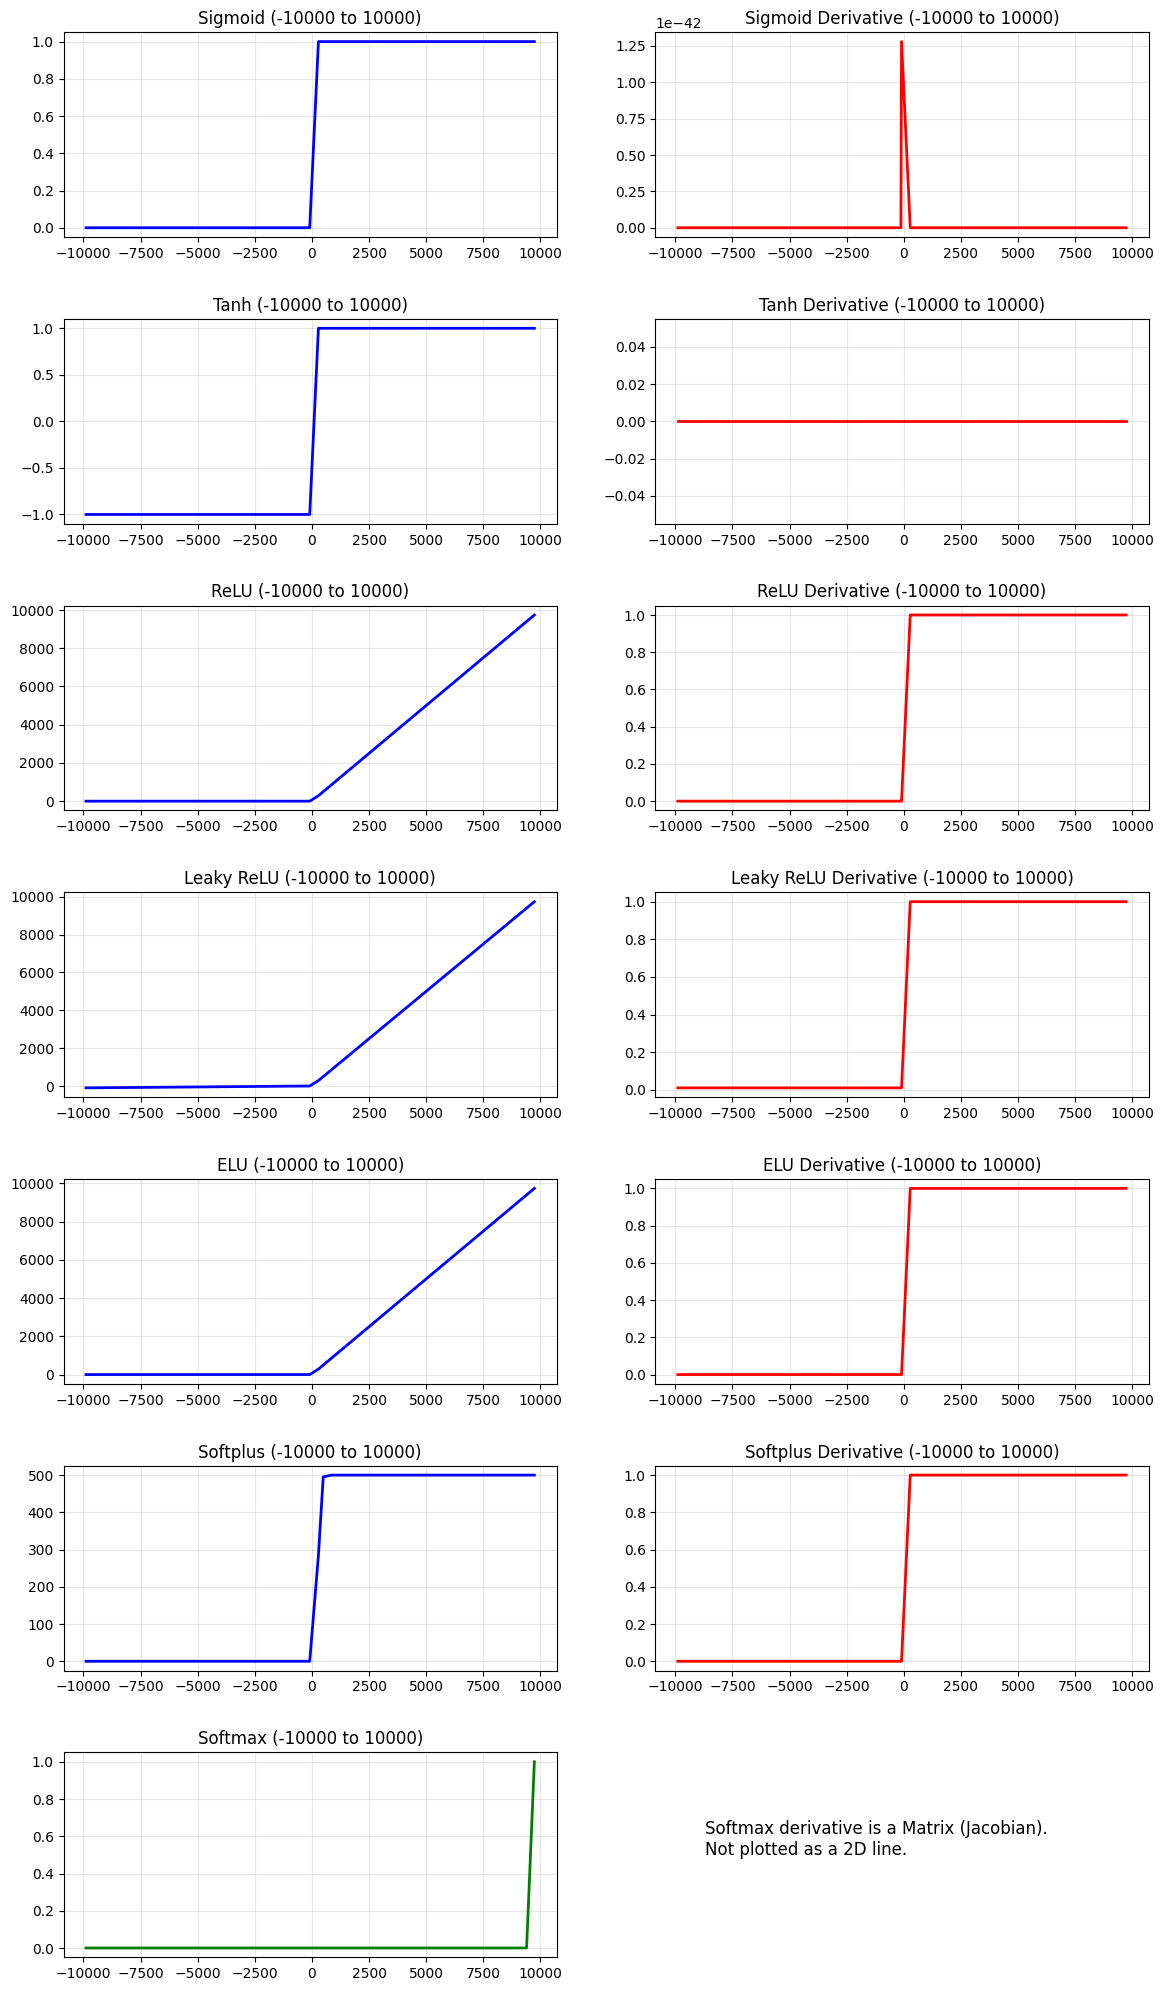

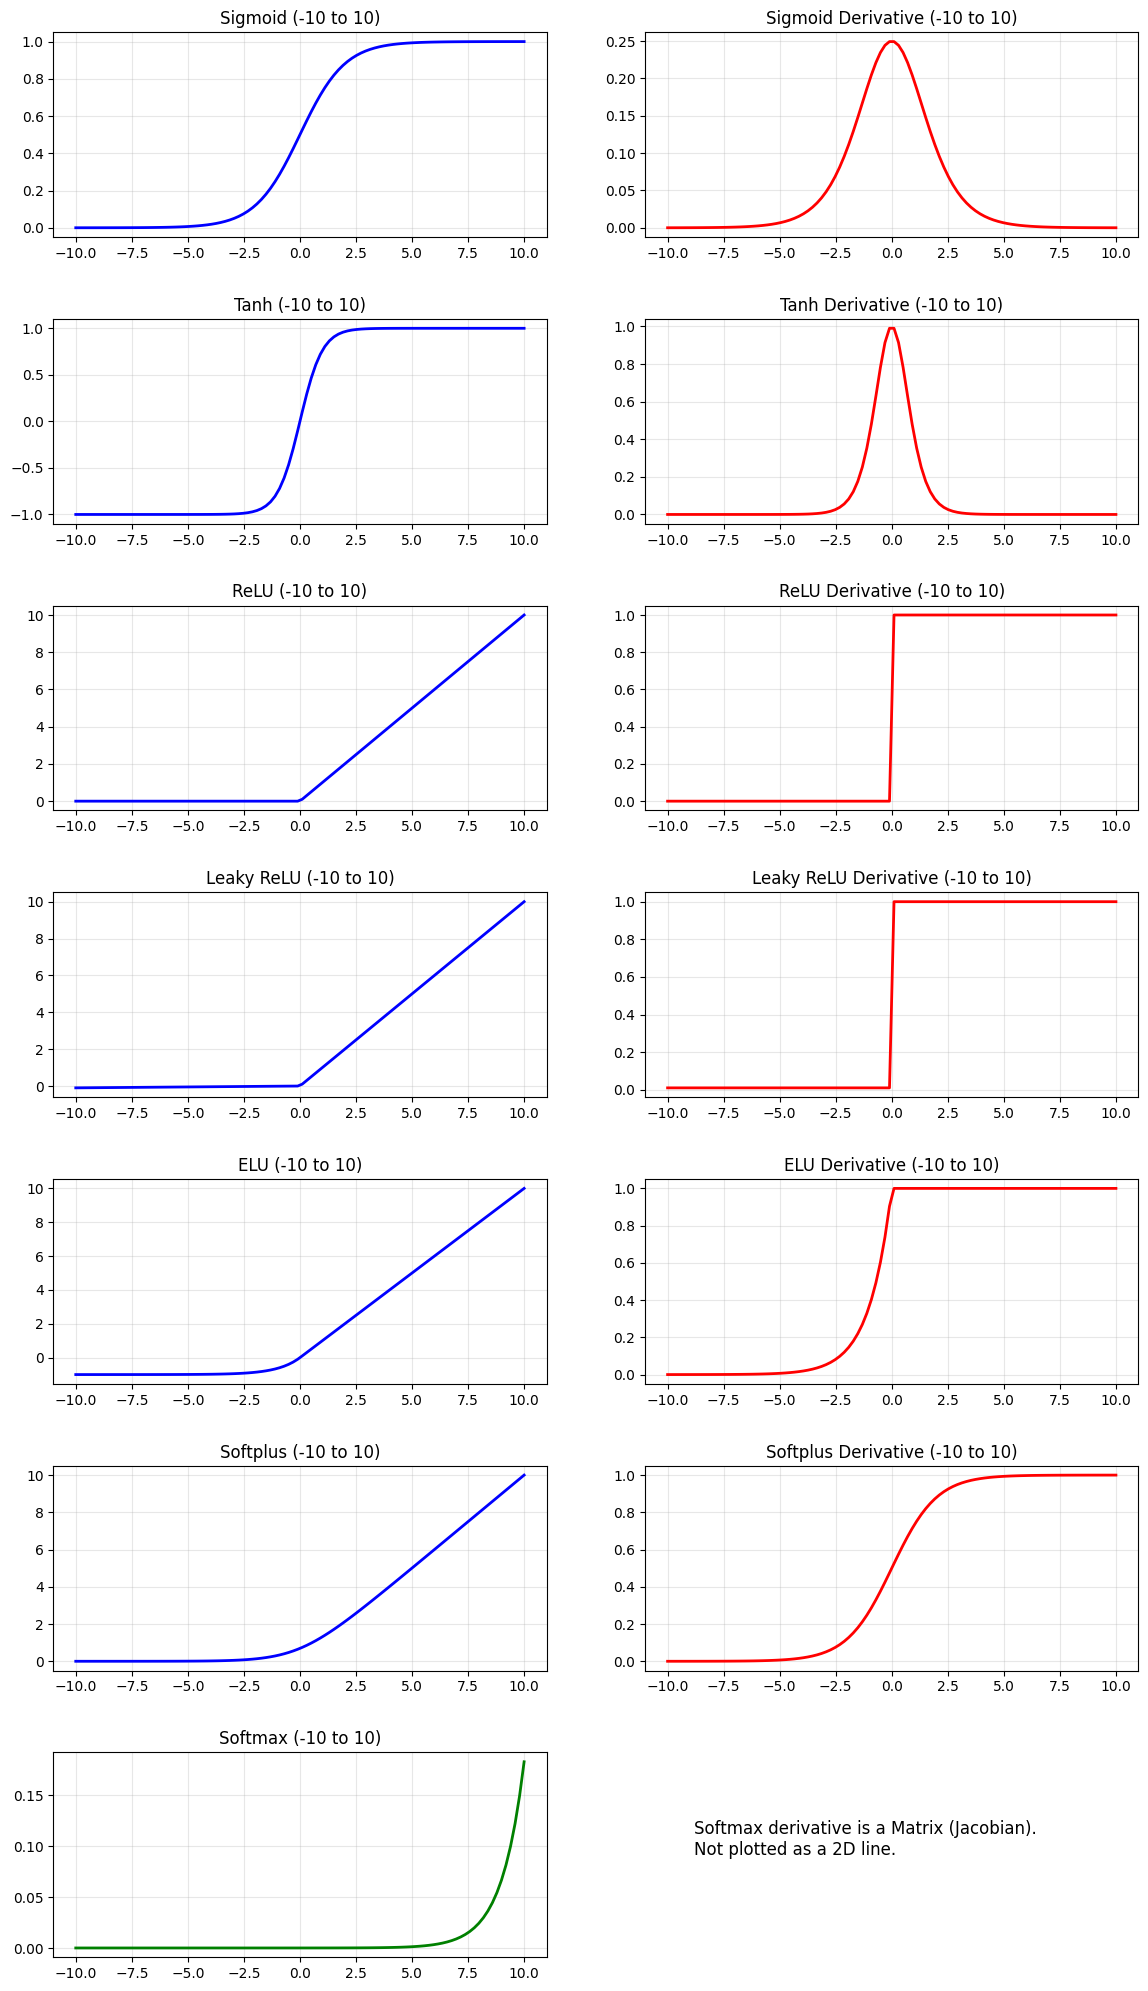

In [4]:
def create_plot(data, filename, title_range):
    funcs = {
        "Sigmoid": (sigmoid, d_sigmoid),
        "Tanh": (tanh, d_tanh),
        "ReLU": (relu, d_relu),
        "Leaky ReLU": (leaky_relu, d_leaky_relu),
        "ELU": (elu, d_elu),
        "Softplus": (softplus, d_softplus)
    }

    fig, axes = plt.subplots(len(funcs) + 1, 2, figsize=(14, 25))
    plt.subplots_adjust(hspace=0.4)

    for i, (name, (f, df)) in enumerate(funcs.items()):

        axes[i, 0].plot(data, f(data), color='blue', lw=2)
        axes[i, 0].set_title(f"{name} {title_range}")
        axes[i, 0].grid(alpha=0.3)

        axes[i, 1].plot(data, df(data), color='red', lw=2)
        axes[i, 1].set_title(f"{name} Derivative {title_range}")
        axes[i, 1].grid(alpha=0.3)

    axes[-1, 0].plot(data, softmax(data), color='green', lw=2)
    axes[-1, 0].set_title(f"Softmax {title_range}")
    axes[-1, 0].grid(alpha=0.3)

    axes[-1, 1].axis('off')
    axes[-1, 1].text(0.1, 0.5, "Softmax derivative is a Matrix (Jacobian).\nNot plotted as a 2D line.", fontsize=12)

    plt.savefig(filename)
    print(f"Plot saved as {filename}")

create_plot(x_values, "activations_wide.png", "(-10000 to 10000)")

x_zoom = np.linspace(-10, 10, 100)
create_plot(x_zoom, "activations_zoom.png", "(-10 to 10)")